# Prophet

(Simple overview of what prophet is)

## Data preparation

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [77]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [78]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tdiff']
})

data.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True)

data

c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
c:\Users\gjpin\Documents\GitHub\TSF-PROJ\utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

,ds,y
date,,
1995-01-01,1995-01-01,8.19
1995-02-01,1995-02-01,8.50
1995-03-01,1995-03-01,11.09
1995-04-01,1995-04-01,12.96
1995-05-01,1995-05-01,11.03
...,...,...
2019-09-01,2019-09-01,14.10
2019-10-01,2019-10-01,11.34
2019-11-01,2019-11-01,7.18


In [79]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

print(len(test))
print(train.dtypes)
y_test

61
ds    datetime64[ns]
y            float64
dtype: object


date
2015-01-01    10.75
2015-02-01     8.84
2015-03-01    12.11
2015-04-01    11.64
2015-05-01    13.58
              ...  
2019-09-01    14.10
2019-10-01    11.34
2019-11-01     7.18
2019-12-01     8.46
2020-01-01     8.65
Name: y, Length: 61, dtype: float64

## Modelling

In [80]:
from prophet import Prophet

model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=len(test), freq='MS')

future

21:05:04 - cmdstanpy - INFO - Chain [1] start processing
21:05:04 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,1995-01-01
1,1995-02-01
2,1995-03-01
3,1995-04-01
4,1995-05-01
...,...
296,2019-09-01
297,2019-10-01
298,2019-11-01
299,2019-12-01


In [81]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
296,2019-09-01,12.592175,11.024578,14.156825
297,2019-10-01,11.229946,9.688491,12.917312
298,2019-11-01,9.139937,7.535121,10.706491
299,2019-12-01,9.132290,7.560190,10.674544
300,2020-01-01,9.561696,8.052959,11.146567


In [82]:
evaluate(y_test, forecast['yhat'][-len(test):])

MAE: 1.3028973746849974
RMSE: 1.564541091680638


Text(0.5, 1.0, 'Prophet Forecast')

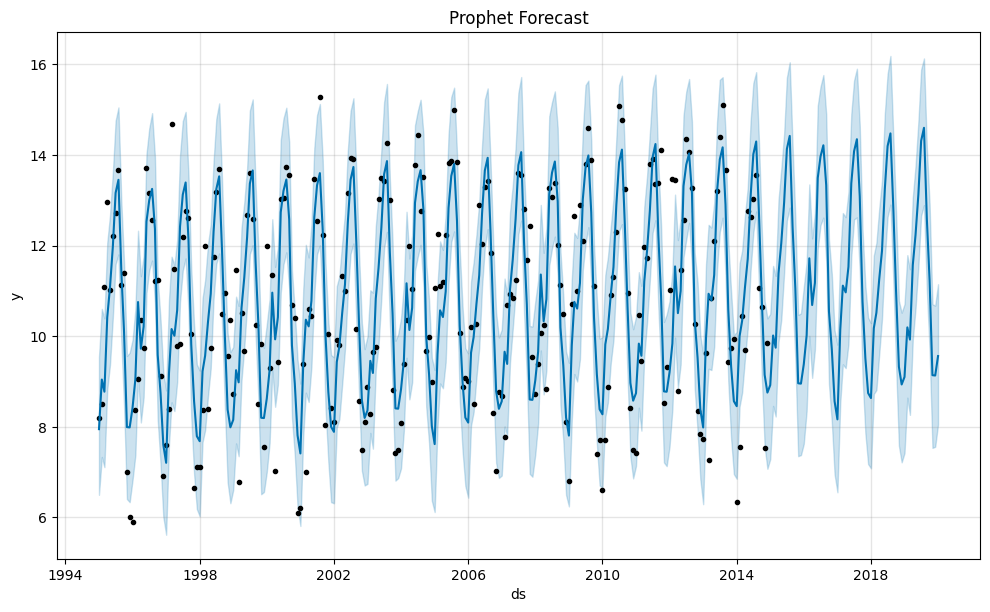

In [83]:
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")

Text(0.5, 1.02, 'Prophet Forecast Components')

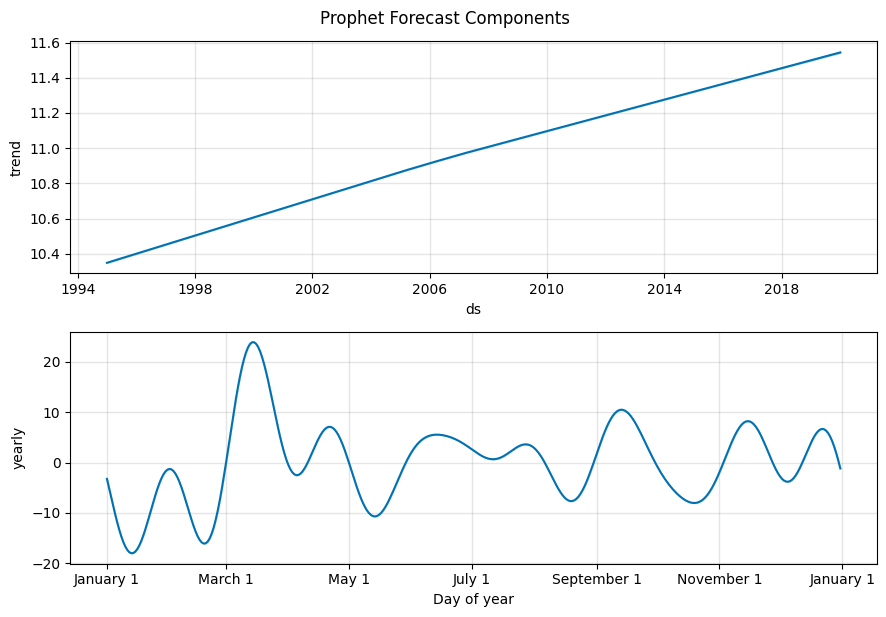

In [84]:
fig2 = model.plot_components(forecast)
plt.suptitle("Prophet Forecast Components", y=1.02)

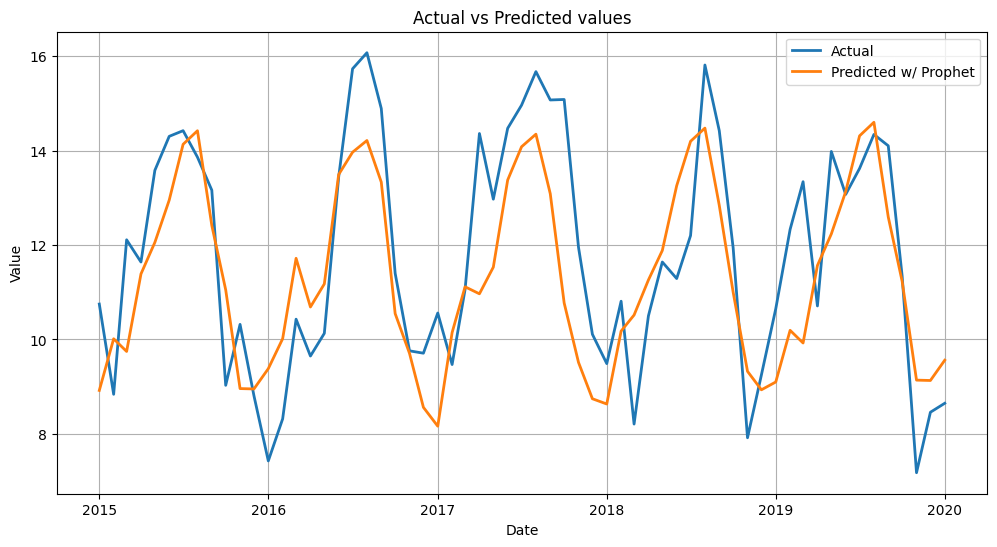

In [85]:
# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

## Hyperparameter Tuning

In [86]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
import itertools


param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5, 1.0],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0, 20.0],
}

all_params = [
    dict(zip(param_grid.keys(), v))
    for v in itertools.product(*param_grid.values())
]

rmses = []

for params in all_params:
    m = Prophet(**params).fit(train)
    future = m.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    rmses.append(np.sqrt(mean_squared_error(y_test, forecast['yhat'][-len(test):])))

tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
print(tuning_results)

21:05:05 - cmdstanpy - INFO - Chain [1] start processing
21:05:05 - cmdstanpy - INFO - Chain [1] done processing
21:05:05 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:05:05 - cmdstanpy - INFO - Chain [1] start processing
21:05:05 - cmdstanpy - INFO - Chain [1] done processing
21:05:05 - cmdstanpy - INFO - Chain [1] start processing
21:05:05 - cmdstanpy - INFO - Chain [1] done processing
21:05:05 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:05:05 - cmdstanpy - INFO - Chain [1] start processing
21:05:05 - cmdstanpy - INFO - Chain [1] done processing
21:05:06 - cmdstanpy - INFO - Chain [1] start processing
21:05:06 - cmdstanpy - INFO - Chain [1] done processing
21:05:06 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:05:06 - c

    changepoint_prior_scale  seasonality_prior_scale      rmse
0                     0.001                     0.01  1.564541
1                     0.001                     0.10  1.564541
2                     0.001                     1.00  1.564541
3                     0.001                    10.00  1.564541
4                     0.001                    20.00  1.564541
5                     0.010                     0.01  1.564541
6                     0.010                     0.10  1.564541
7                     0.010                     1.00  1.564541
8                     0.010                    10.00  1.564541
9                     0.010                    20.00  1.564541
10                    0.100                     0.01  1.564541
11                    0.100                     0.10  1.564541
12                    0.100                     1.00  1.564541
13                    0.100                    10.00  1.564541
14                    0.100                    20.00  1